In [58]:
import numpy as np
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt

In [59]:
X,Y = load_diabetes(return_X_y=True)

In [60]:
print(X.shape)
print(Y.shape)

(442, 10)
(442,)


In [61]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [62]:
class CustomLinearRegression:
  def __init__(self):
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train,Y_train):
    X_train = np.insert(X_train,0,1,axis=1)
    betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(Y_train)
    self.intercept_ = betas[0]
    self.coef_ = betas[1:]

  def predict(self,X_test):
    y_pred = np.dot(X_test,self.coef_) + self.intercept_
    return y_pred


In [63]:
lr = CustomLinearRegression()

lr.fit(X_train,Y_train)

In [64]:
y_pred = lr.predict(X_test)
print(y_pred)
print(y_pred.shape)

[154.1213881  204.81835118 124.93755353 106.08950893 258.5348576
 256.3310074  118.75087616 119.52440696 101.50816735 190.54048661
 141.70656811 172.51883961 174.33861649 134.80942706 294.13994537
  94.11798038 211.97059795 156.49579378 134.21000428 119.62664644
 148.87842251 165.00873409 151.10021038 176.04063756 133.27769647
 221.29555392 197.17324941  96.1577688   50.26012711 230.48580317
 242.06073866 114.11129218  67.07532417  94.52943825 201.21415375
 167.05136201 159.881268   192.78746659 114.49551325 233.48234551
 140.82563045 121.0680409  192.27480772 191.12738845 179.16865788
 148.34935601 163.47414622 276.81647884 100.17926432 164.10555298
 255.80762189 136.9466204  152.37503699 107.92237882 194.21924678
  77.34670792 118.50482479  68.38335763 154.29258529 162.48840259
 168.36788326 156.87790322  97.14191797 238.1671215  145.46179904
 117.65702433 168.88784311 198.38683887 118.24053714 124.64552812
 223.17700368 200.63012386 129.54414666 158.1584765  154.332565
 114.47070769

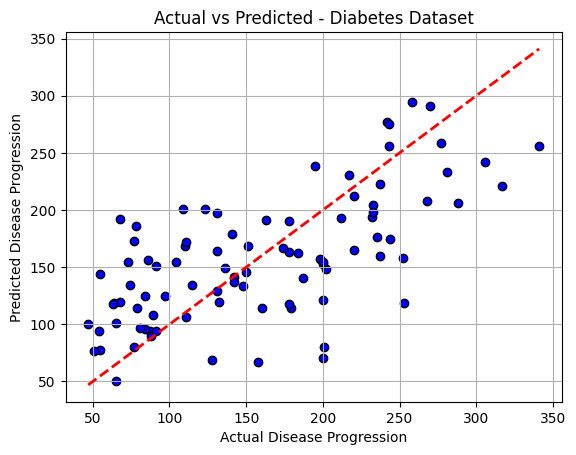

In [65]:
plt.scatter(Y_test, y_pred, color='blue', edgecolors='k')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs Predicted - Diabetes Dataset")
plt.grid(True)
plt.show()

In [66]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [67]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)

In [68]:
from sklearn.metrics import r2_score

r2_score(y_test,y_pred)

0.4399338661568968

In [69]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


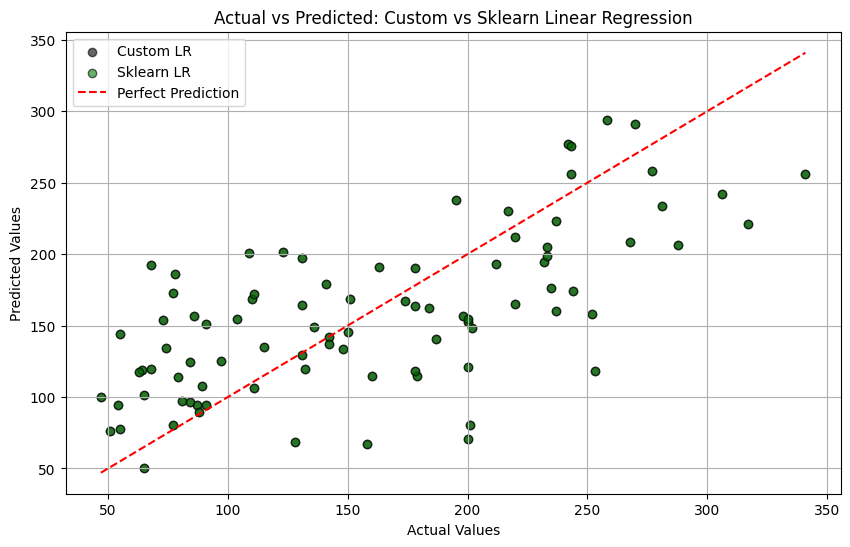

In [70]:
custom_lr = CustomLinearRegression()
custom_lr.fit(X_train, y_train)
y_pred_custom = custom_lr.predict(X_test)

# Predictions from sklearn model (already trained above)
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred_sklearn = reg.predict(X_test)

# Plotting Actual vs Predicted for both models
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_custom, color='black', alpha=0.6, label='Custom LR', edgecolor='k')
plt.scatter(y_test, y_pred_sklearn, color='green', alpha=0.6, label='Sklearn LR', edgecolor='k')

# Perfect prediction reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted: Custom vs Sklearn Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
print("Custom Model R² Score:", r2_score(y_test, y_pred_custom))
print("Sklearn Model R² Score:", r2_score(y_test, y_pred_sklearn))

Custom Model R² Score: 0.43993386615689634
Sklearn Model R² Score: 0.4399338661568968
